# Zillow Home Sales Forecasting Benchmark (Machine learning)

This notebook benchmarks machine learning models for monthly home sales forecasting using Zillow metropolitan sales-count data.

The goal is to compare LightGBM, XGBoost, and CatBoost under the same walk-forward cross-validation setup across a cross-sectional hierarchy.

## Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, RollingMax, ExpandingMean

plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})

## Data

In [2]:
df = pd.read_csv("Data/zillow_houses_hierarchy_cleaned.csv", parse_dates=["ds"])
data = df[["unique_id", "ds", "y"]].copy()
display(data.head())

,unique_id,ds,y
0,US,2008-02-29,174474.0
1,US,2008-03-31,203564.0
2,US,2008-04-30,225601.0
3,US,2008-05-31,248297.0
4,US,2008-06-30,260848.0


## Static series identifiers

One-hot encoded series identifiers are added as static features. These features allow tree-based models to learn persistent differences across markets while keeping a single global forecasting model for all series.

In [3]:
# Create and add static features (series_id) (One-hot encoding)
uids = data["unique_id"].drop_duplicates().reset_index(drop = True)
static = pd.get_dummies(uids, dtype = int)
static.columns = [f"id_{i}" for i in range(static.shape[1])]
static.index = uids.values
static.index.name = "unique_id"
static = static.reset_index()
data_full = data.merge(static, on = "unique_id", how = "left")

In [4]:
display(data_full)

,unique_id,ds,y,id_0,id_1,id_2,id_3,id_4,id_5,id_6,...,id_340,id_341,id_342,id_343,id_344,id_345,id_346,id_347,id_348,id_349
0,US,2008-02-29,174474.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,US,2008-03-31,203564.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,US,2008-04-30,225601.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,US,2008-05-31,248297.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,US,2008-06-30,260848.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76295,US|WV|394455,2025-11-30,160.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
76296,US|WV|394455,2025-12-31,206.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
76297,US|WV|394455,2026-01-31,129.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
76298,US|WV|394455,2026-02-28,125.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
display(data['unique_id'].unique())

<ArrowStringArray>
[          'US',        'US|AK',        'US|AL',        'US|AR',
        'US|AZ',        'US|CA',        'US|CO',        'US|CT',
        'US|DE',        'US|FL',
 ...
 'US|WI|394334', 'US|WI|394555', 'US|WI|394646', 'US|WI|394720',
 'US|WI|394816', 'US|WI|394862', 'US|WI|394944', 'US|WI|395011',
 'US|WI|395215', 'US|WV|394455']
Length: 350, dtype: str

## Autocorrelation diagnostics

The national monthly series is inspected with partial autocorrelation plots to identify relevant lag structure and annual seasonality. Since the data are monthly, special attention is given to 12-month seasonal lags.

In [6]:
# National series for PACF
ts = (
    data[data["unique_id"] == "US"]
    .sort_values("ds")
    .set_index("ds")["y"]
)

print("Start:", ts.index.min())
print("End:", ts.index.max())
print("Observations:", len(ts))

Start: 2008-02-29 00:00:00
End: 2026-03-31 00:00:00
Observations: 218


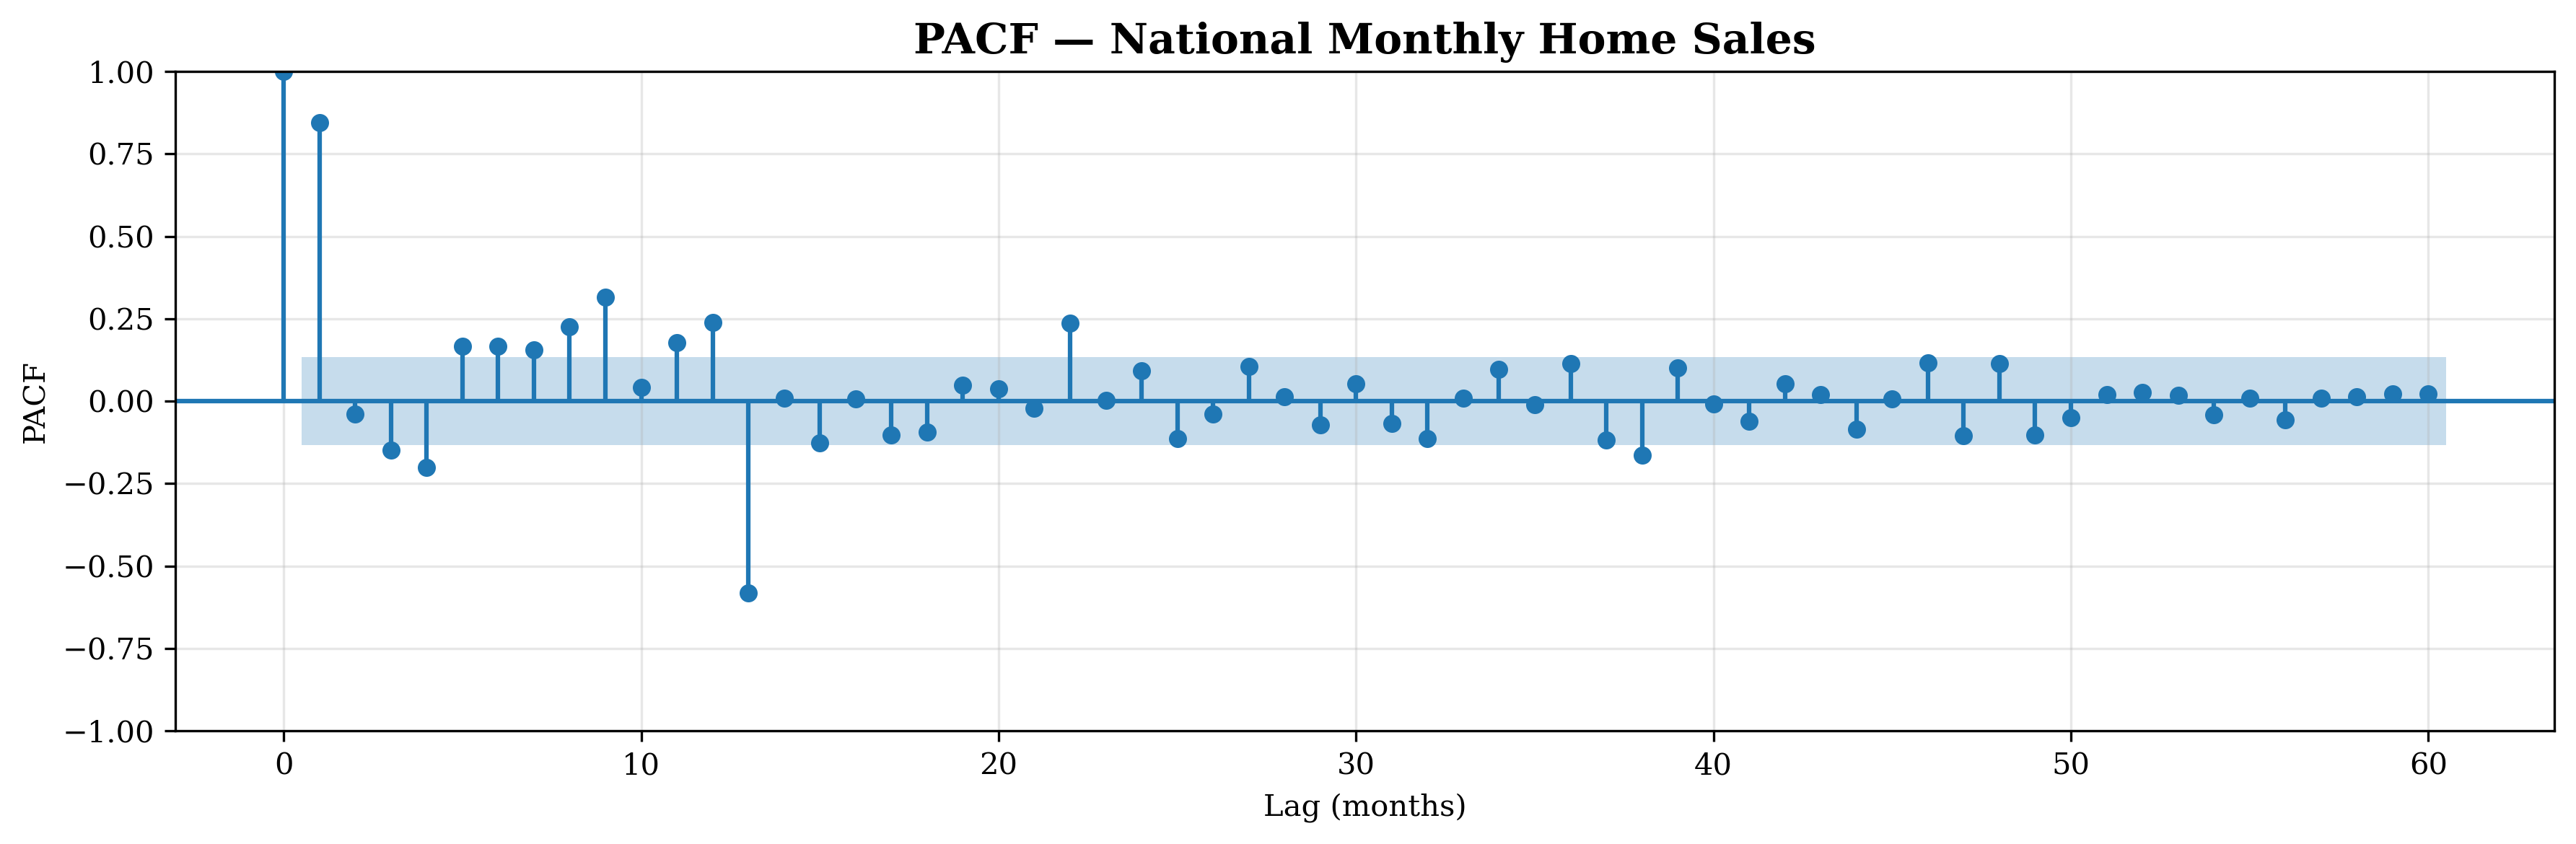

In [7]:
# PACF — national monthly sales
fig, ax = plt.subplots(figsize=(12, 4))

plot_pacf(ts, lags=60, method="ywmle", ax=ax)

ax.set_title("PACF — National Monthly Home Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("PACF")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

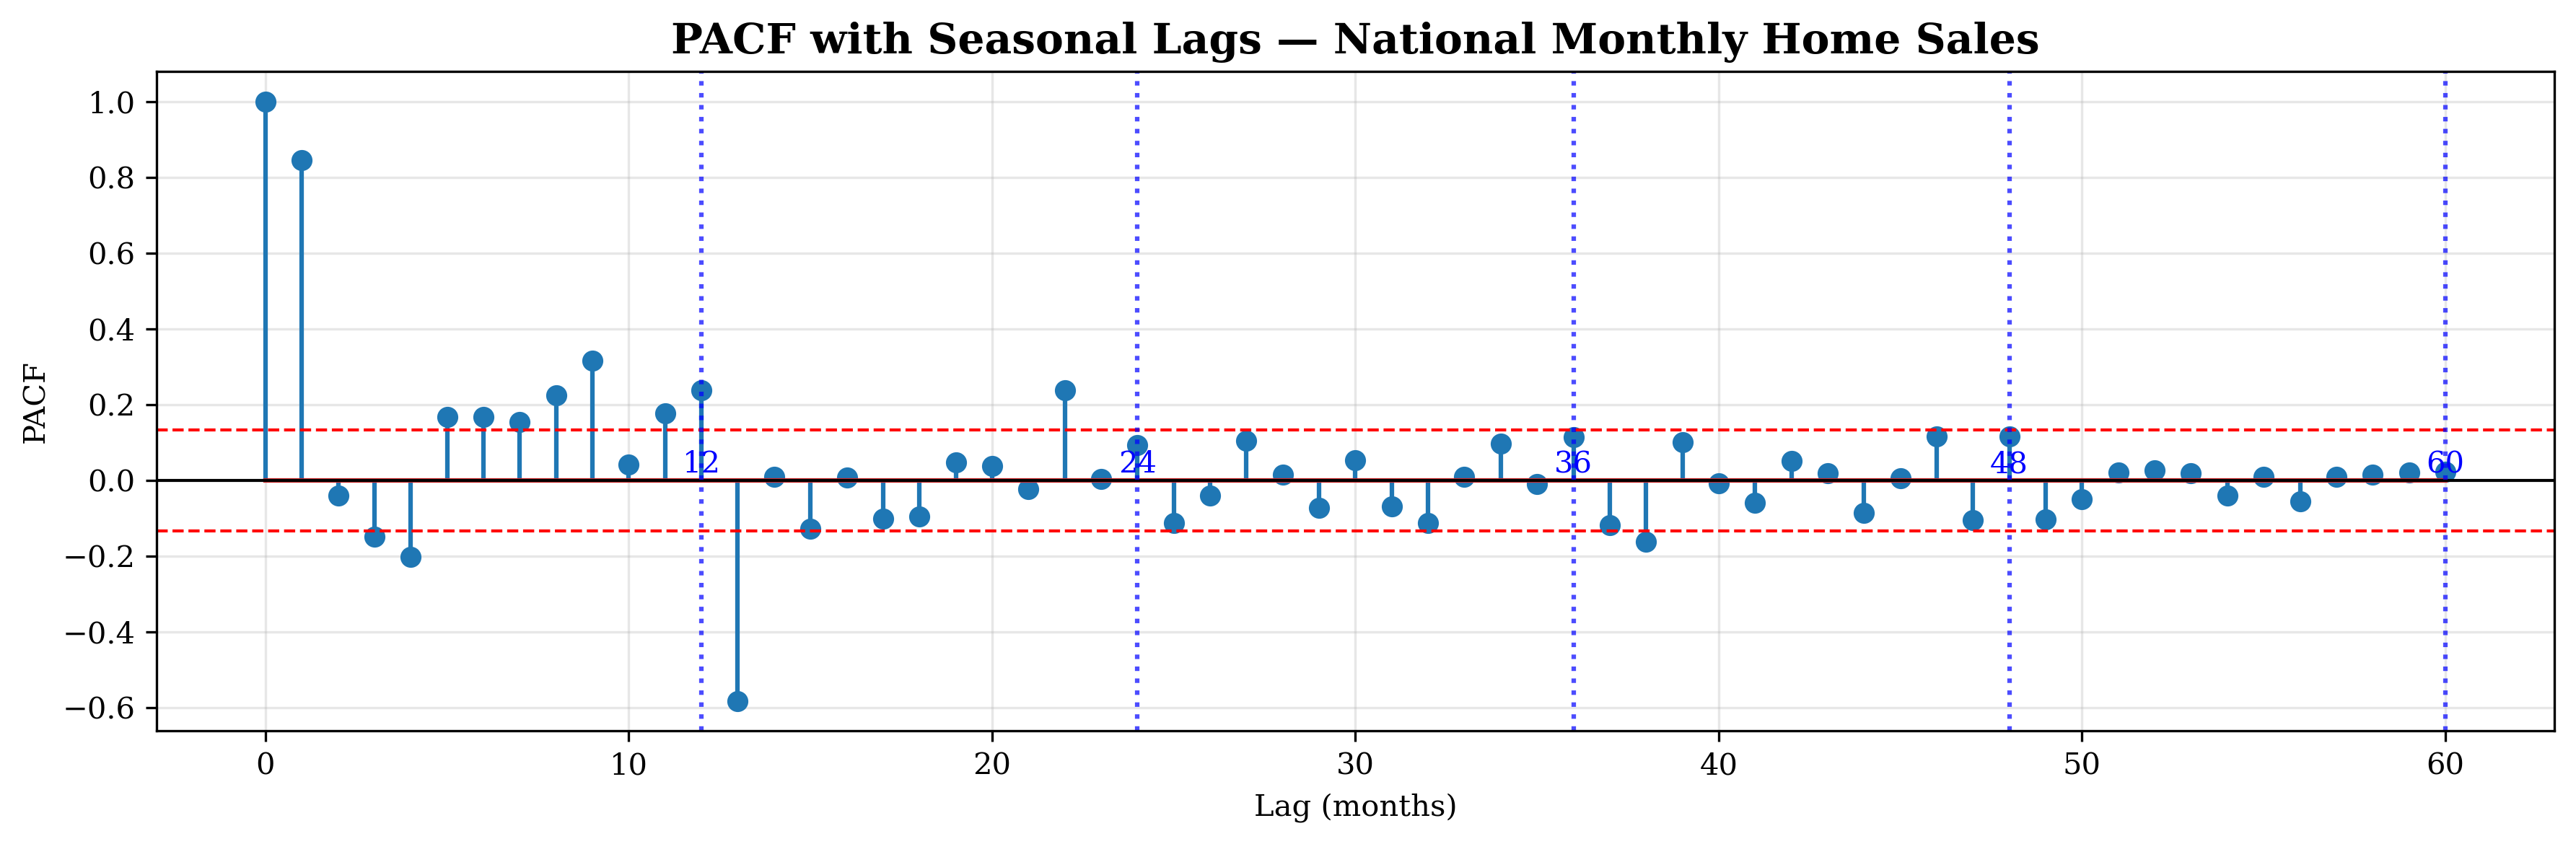

In [8]:
# PACF with seasonal monthly lags
pacf_vals = pacf(ts, nlags=60, method="ywmle")
conf = 1.96 / np.sqrt(len(ts))

fig, ax = plt.subplots(figsize=(12, 4))

ax.stem(range(len(pacf_vals)), pacf_vals)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(conf, color="red", linestyle="--", linewidth=1)
ax.axhline(-conf, color="red", linestyle="--", linewidth=1)

for lag in [12, 24, 36, 48, 60]:
    ax.axvline(lag, color="blue", linestyle=":", alpha=0.7)
    ax.text(lag, 0.02, str(lag), color="blue", ha="center")

ax.set_title("PACF with Seasonal Lags — National Monthly Home Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("PACF")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

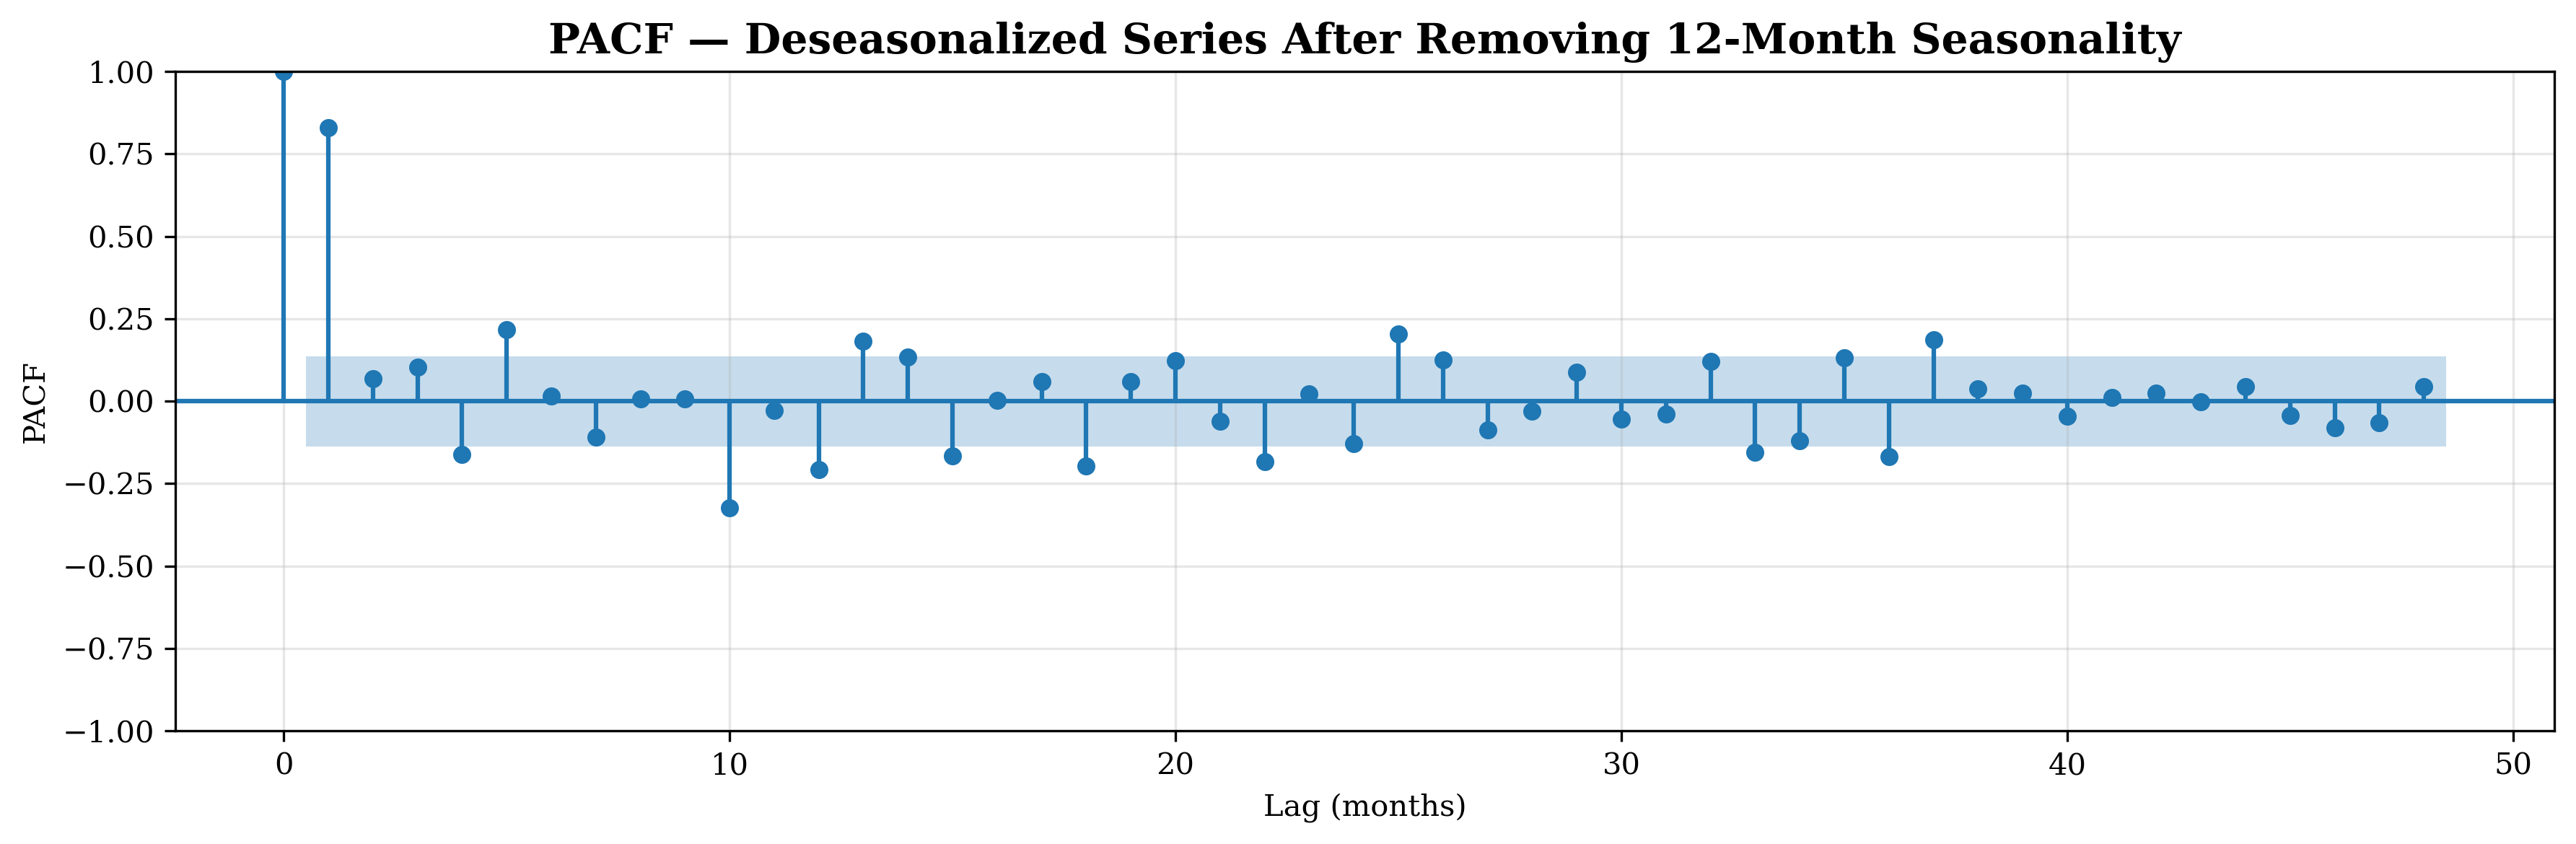

In [9]:
# PACF after removing annual seasonality
ts_deseason = ts - ts.shift(12)
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(ts_deseason.dropna(), lags=48, method="ywmle", ax=ax)
ax.set_title("PACF — Deseasonalized Series After Removing 12-Month Seasonality", fontsize=14, fontweight="bold")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("PACF")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Zero-value diagnostics

Zero counts are reviewed to identify markets with incomplete coverage or months with no recorded sales. This check helps verify whether sparse series may affect model training and evaluation.

In [10]:
zero_summary = (data.groupby("unique_id")
    .agg(n_obs=("y", "size"),
        n_zeros=("y", lambda x: (x == 0).sum()),
        zero_share=("y", lambda x: (x == 0).mean()),
        min_y=("y", "min"),
        mean_y=("y", "mean"),
        total_y=("y", "sum"))
    .reset_index())

zero_summary["series_type"] = np.select([zero_summary["n_zeros"].eq(0), zero_summary["n_zeros"].eq(zero_summary["n_obs"])],
                                        ["never_zero", "always_zero"],
                                        default="has_zeros")

zero_counts = (zero_summary["series_type"]
    .value_counts()
    .rename_axis("series_type")
    .reset_index(name="n_series"))
display(zero_counts)
display(zero_summary.sort_values(["zero_share", "n_zeros"], ascending=False).head(30))

,series_type,n_series
0,never_zero,322
1,has_zeros,28


,unique_id,n_obs,n_zeros,zero_share,min_y,mean_y,total_y,series_type
230,US|NY|845159,218,158,0.724771,0.0,86.862385,18936.0,has_zeros
4,US|AL|394351,218,85,0.389908,0.0,111.238532,24250.0,has_zeros
182,US|MT,218,42,0.192661,0.0,152.862385,33324.0,has_zeros
183,US|MT|394386,218,42,0.192661,0.0,152.862385,33324.0,has_zeros
310,US|TX|395197,218,35,0.160550,0.0,187.027523,40772.0,has_zeros
276,US|SD,218,13,0.059633,0.0,267.720183,58363.0,has_zeros
277,US|SD|395103,218,13,0.059633,0.0,267.720183,58363.0,has_zeros
301,US|TX|394692,218,4,0.018349,0.0,5511.532110,1201514.0,has_zeros
24,US|AZ|845160,218,2,0.009174,0.0,406.073394,88524.0,has_zeros
175,US|MO|394729,218,2,0.009174,0.0,183.940367,40099.0,has_zeros


## Forecasting setup

The forecasting task uses a 12-month horizon with five walk-forward validation windows. Lag features and rolling statistics are used to capture short-term dynamics, annual seasonality, and local trend behavior.

## Machine learning models

Three gradient boosting models are benchmarked: LightGBM, XGBoost, and CatBoost. All models are trained under the same feature set and validation protocol to keep the comparison consistent.

In [11]:
horizon = 12
n_windows = 5
step_size = 12
freq = "ME"

lags = [1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 24]

lag_transforms = {
    1: [
        RollingMean(3, min_samples=2),
        RollingMean(6, min_samples=3),
        RollingMean(12, min_samples=6),
        RollingStd(3, min_samples=2),
        RollingStd(6, min_samples=3),
        RollingMax(6, min_samples=3),
        ExpandingMean()
    ],
    12: [
        RollingMean(3, min_samples=2),
        RollingMean(6, min_samples=3),
        RollingStd(3, min_samples=2)
    ]
}

In [12]:
models = {
    "LightGBM": lgb.LGBMRegressor(
        objective="tweedie",
        tweedie_variance_power=1.3,
        metric="mae",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        objective="reg:tweedie",
        tweedie_variance_power=1.3,
        eval_metric="mae",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        loss_function="Tweedie:variance_power=1.3",
        eval_metric="MAE",
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )
}

## Walk-forward cross-validation

Models are evaluated using walk-forward cross-validation. Each window trains on historical observations and forecasts the next 12 months, providing a realistic evaluation of out-of-sample forecasting performance.

In [13]:
mlf = MLForecast(
    models=models,
    freq=freq,
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=["month", "quarter", "year"]
)

t0 = time.perf_counter()

cv_raw = mlf.cross_validation(
    df=data_full,
    h=horizon,
    n_windows=n_windows,
    step_size=step_size,
    refit=True,
    fitted=True,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[c for c in data_full.columns if c.startswith("id_")]
)

cv_time = time.perf_counter() - t0

print(f"✓ MLForecast CV completed in {cv_time:.2f} seconds")
print(f"✓ Windows: {cv_raw['cutoff'].nunique()}")
print(f"✓ Rows: {len(cv_raw):,}")
display(cv_raw.head())

✓ MLForecast CV completed in 44.81 seconds
✓ Windows: 5
✓ Rows: 21,000


,unique_id,ds,cutoff,y,LightGBM,XGBoost,CatBoost
0,US,2021-04-30,2021-03-31,431346.0,408514.066637,339081.06250,336268.603753
1,US,2021-05-31,2021-03-31,434753.0,435912.926540,358487.81250,319935.160379
2,US,2021-06-30,2021-03-31,508881.0,489154.418220,437807.00000,371661.953050
3,US,2021-07-31,2021-03-31,476737.0,494602.680796,486840.43750,420969.678289
4,US,2021-08-31,2021-03-31,468873.0,497981.826994,475196.90625,420144.610255


## Forecast formatting

Out-of-sample forecasts and in-sample fitted values are reshaped into a unified long-format table. Negative forecasts are clipped to zero because sales counts cannot be negative.

In [14]:
# Format forecasts (in_sample and out_sample)
id_cols = ["unique_id", "ds", "cutoff", "y"]
model_cols = [c for c in cv_raw.columns if c not in id_cols]

def format_forecasts(df_, sample_type):
    df_ = df_.copy()
    df_["ds"] = pd.to_datetime(df_["ds"])
    df_["cutoff"] = pd.to_datetime(df_["cutoff"])

    out = df_.melt(
        id_vars=id_cols,
        value_vars=model_cols,
        var_name="model",
        value_name="forecast")

    out["forecast"] = out["forecast"].clip(lower=0)
    out["type"] = sample_type
    out["frequency"] = freq

    if sample_type == "out_sample":
        out["horizon"] = (
            (out["ds"].dt.year - out["cutoff"].dt.year) * 12
            + (out["ds"].dt.month - out["cutoff"].dt.month))
    else:
        out["horizon"] = np.nan
    return out

# Out-of-sample forecasts
cv_out = format_forecasts(cv_raw, "out_sample")

# In-sample fitted values
cv_fitted_raw = mlf.cross_validation_fitted_values().copy()

if "cutoff" not in cv_fitted_raw.columns:
    cutoff_map = (
        cv_raw[["cutoff"]]
        .drop_duplicates()
        .sort_values("cutoff")
        .reset_index(drop=True)
        .assign(fold=lambda x: x.index))

    cv_fitted_raw = cv_fitted_raw.merge(cutoff_map, on="fold", how="left")

cv_in = format_forecasts(cv_fitted_raw, "in_sample")

# Metadata
meta = (df[["unique_id", "RegionName", "StateName", "hierarchy_level"]].drop_duplicates("unique_id"))

# Final dataset
pred_all = (pd.concat([cv_in, cv_out], ignore_index=True)
    .merge(meta, on="unique_id", how="left")
    .assign(cv_time_seconds=cv_time,
            horizon_config=horizon,
            n_windows=n_windows,
            step_size=step_size,
            lags=",".join(map(str, lags)),
            features="month_quarter_year",
            lag_transforms="rolling_mean_std_max_expanding_mean"))

pred_all = pred_all[[
        "unique_id", "ds", "cutoff", "y", "forecast", "model",
        "type", "frequency", "horizon",
        "RegionName", "StateName", "hierarchy_level",
        "cv_time_seconds", "horizon_config", "n_windows",
        "step_size", "lags", "features", "lag_transforms"]]

display(pred_all.head())
print(pred_all["type"].value_counts())

,unique_id,ds,cutoff,y,forecast,model,type,frequency,horizon,RegionName,StateName,hierarchy_level,cv_time_seconds,horizon_config,n_windows,step_size,lags,features,lag_transforms
0,US,2010-02-28,2021-03-31,169333.0,172841.643905,LightGBM,in_sample,ME,NaN,United States,NaN,0,44.807086,12,5,12,"1,2,3,4,5,6,9,10,11,12,13,24",month_quarter_year,rolling_mean_std_max_expanding_mean
1,US,2010-03-31,2021-03-31,253250.0,252502.296513,LightGBM,in_sample,ME,NaN,United States,NaN,0,44.807086,12,5,12,"1,2,3,4,5,6,9,10,11,12,13,24",month_quarter_year,rolling_mean_std_max_expanding_mean
2,US,2010-04-30,2021-03-31,268249.0,261071.156418,LightGBM,in_sample,ME,NaN,United States,NaN,0,44.807086,12,5,12,"1,2,3,4,5,6,9,10,11,12,13,24",month_quarter_year,rolling_mean_std_max_expanding_mean
3,US,2010-05-31,2021-03-31,276146.0,276114.217485,LightGBM,in_sample,ME,NaN,United States,NaN,0,44.807086,12,5,12,"1,2,3,4,5,6,9,10,11,12,13,24",month_quarter_year,rolling_mean_std_max_expanding_mean
4,US,2010-06-30,2021-03-31,303646.0,289570.843192,LightGBM,in_sample,ME,NaN,United States,NaN,0,44.807086,12,5,12,"1,2,3,4,5,6,9,10,11,12,13,24",month_quarter_year,rolling_mean_std_max_expanding_mean


type
in_sample     829500
out_sample     63000
Name: count, dtype: int64


In [15]:
display(pred_all
    .query("type == 'out_sample'")
    .groupby("cutoff")["horizon"]
    .agg(["min", "max", "nunique"]))

,min,max,nunique
cutoff,,,
2021-03-31,1.0,12.0,12
2022-03-31,1.0,12.0,12
2023-03-31,1.0,12.0,12
2024-03-31,1.0,12.0,12
2025-03-31,1.0,12.0,12


In [16]:
# Check WFCV windows
out = pred_all.query("type == 'out_sample'").copy()

cutoff_ranges = (
    out.groupby("cutoff")["ds"]
    .agg(start="min", end="max", n_periods="nunique")
    .reset_index())

display(cutoff_ranges)

,cutoff,start,end,n_periods
0,2021-03-31,2021-04-30,2022-03-31,12
1,2022-03-31,2022-04-30,2023-03-31,12
2,2023-03-31,2023-04-30,2024-03-31,12
3,2024-03-31,2024-04-30,2025-03-31,12
4,2025-03-31,2025-04-30,2026-03-31,12


## Output

The final forecast table includes predictions, actual values, model names, hierarchy metadata, validation settings, and runtime information. This file is saved for downstream evaluation, visualization, and reconciliation experiments.

In [17]:
pred_all.to_parquet("Data/zillow_mlforecast_cv_predictions.parquet", index=False)

## Forecast visualization

Forecasts are visualized for one sample series from each hierarchy level. The plots compare actual sales against model forecasts across the walk-forward validation period.

In [18]:
display(pred_all['cutoff'].unique())

<DatetimeArray>
['2021-03-31 00:00:00', '2022-03-31 00:00:00', '2023-03-31 00:00:00',
 '2024-03-31 00:00:00', '2025-03-31 00:00:00']
Length: 5, dtype: datetime64[us]

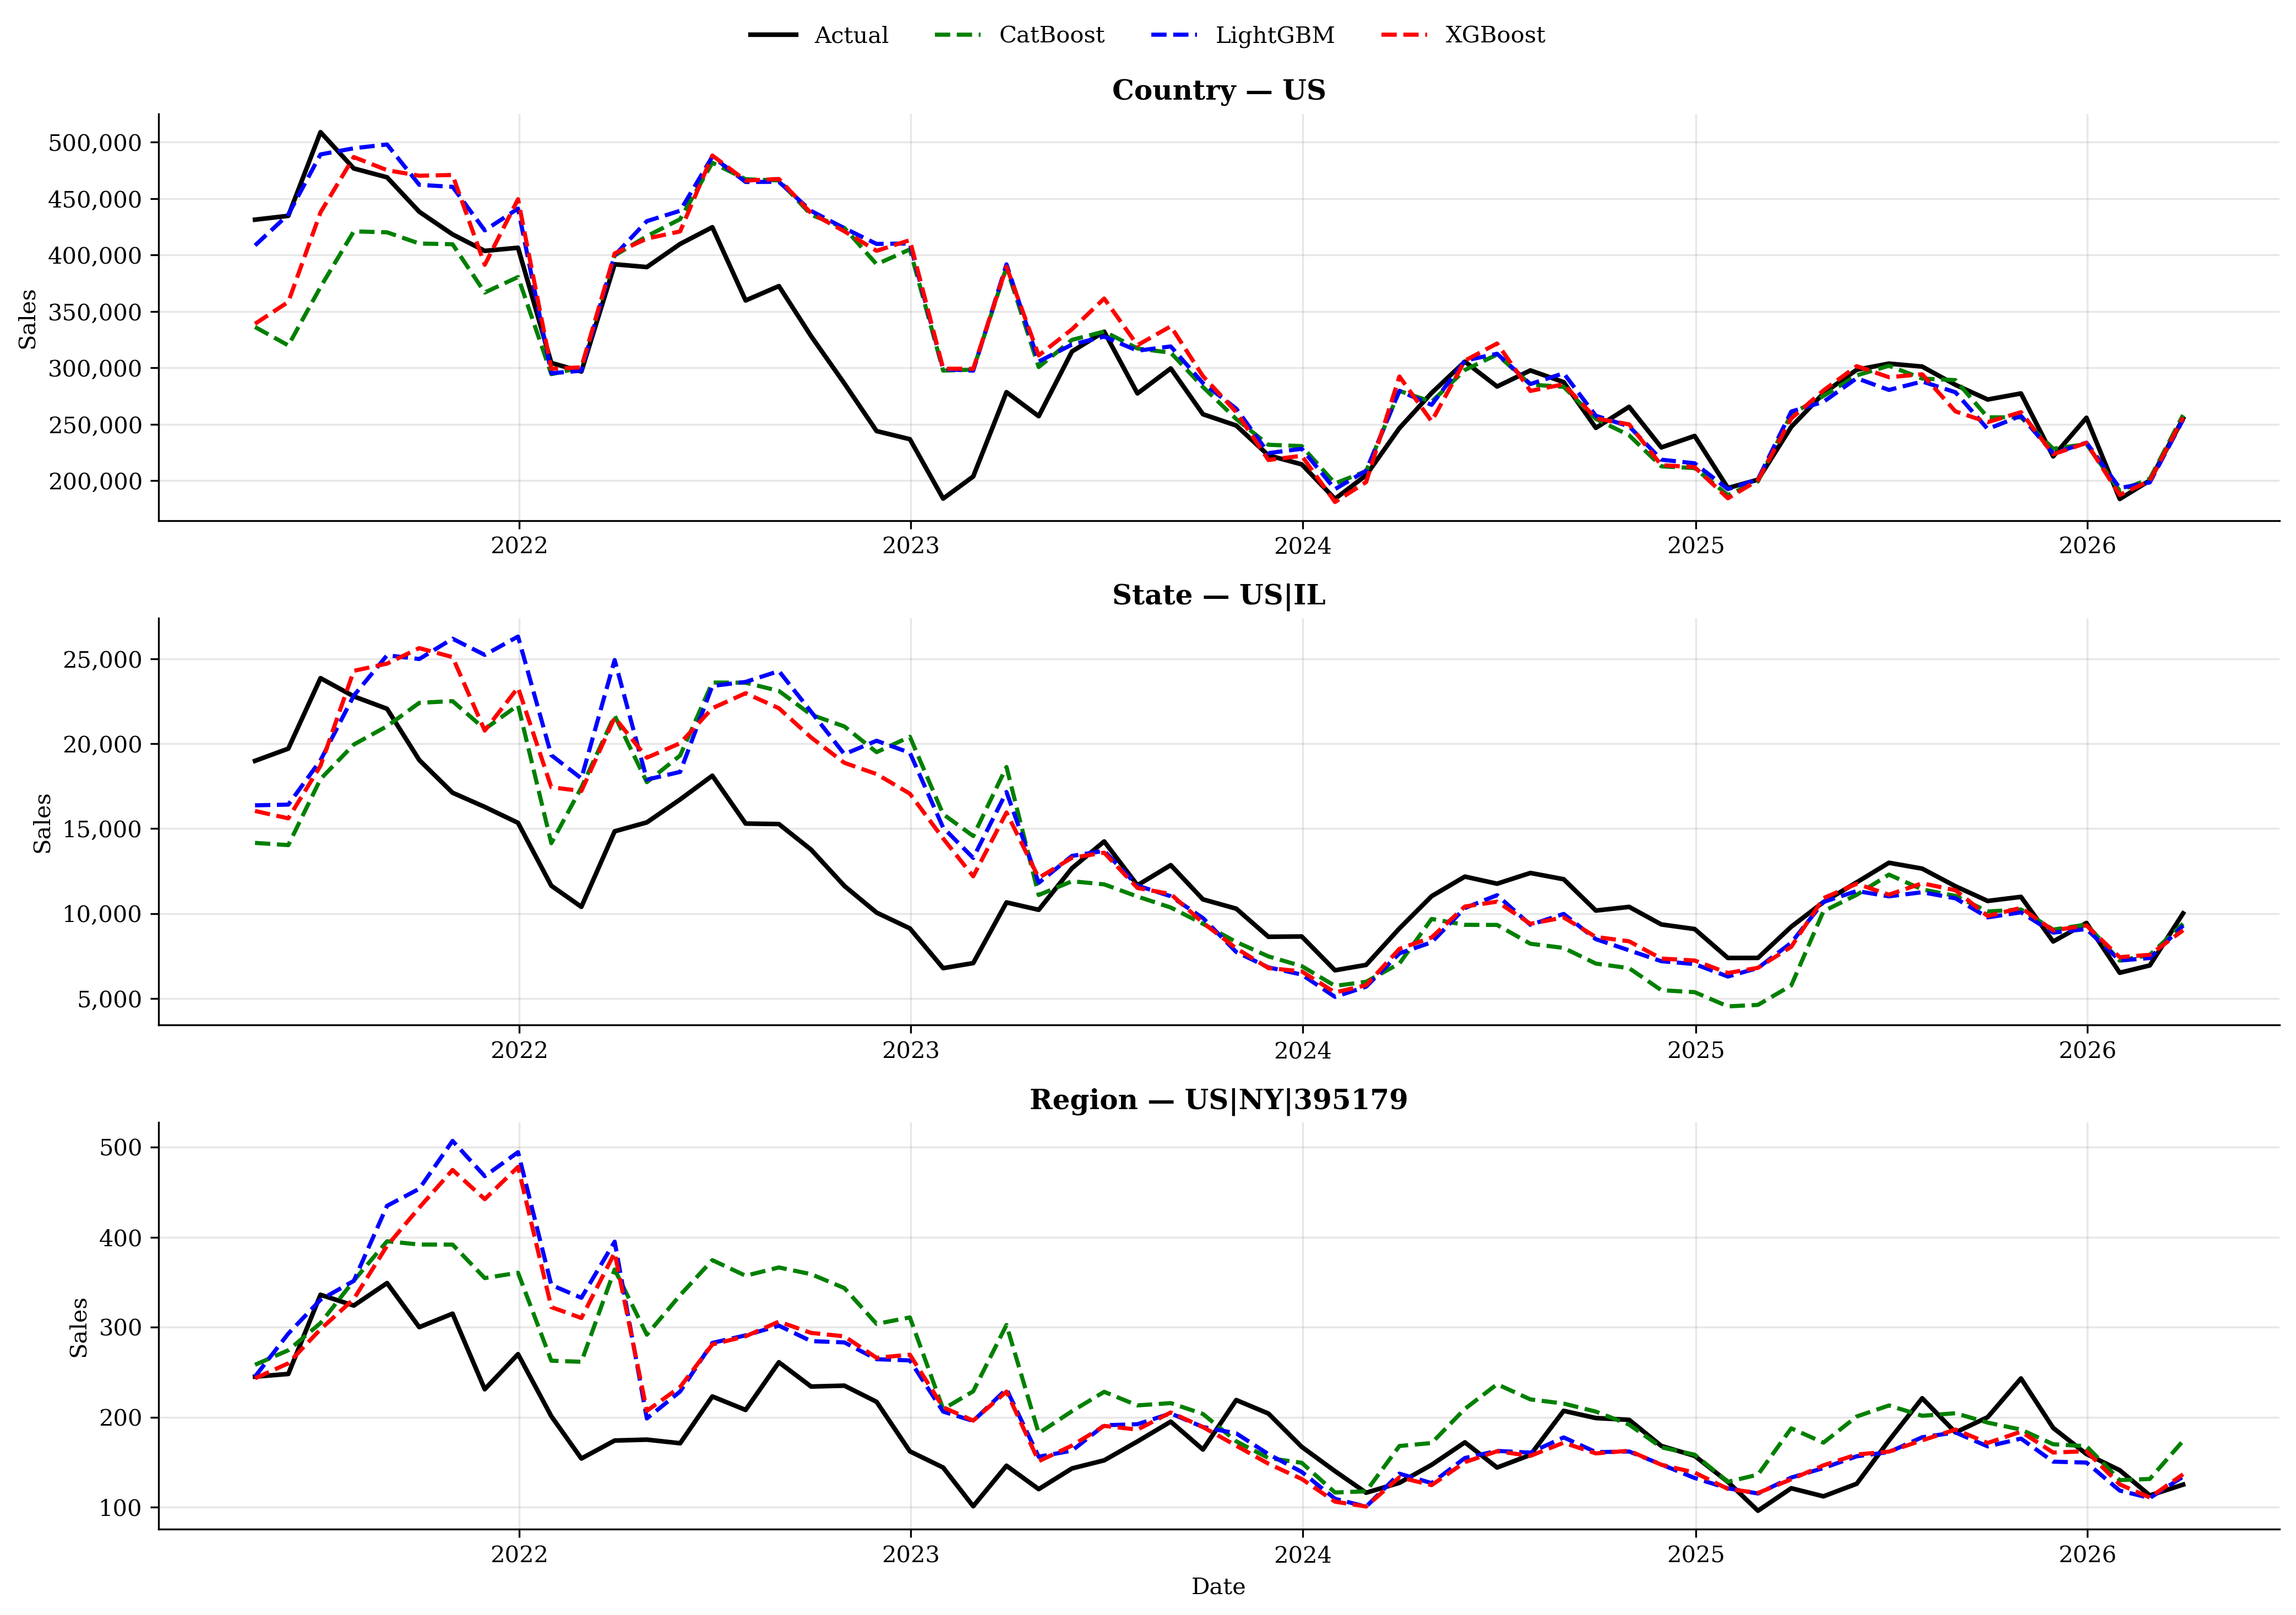

In [19]:
out_df = pred_all.query("type == 'out_sample'").copy()
out_df["ds"] = pd.to_datetime(out_df["ds"])

sample_ids = (
    out_df[["unique_id", "hierarchy_level", "RegionName"]]
    .drop_duplicates()
    .groupby("hierarchy_level", group_keys=False)
    .sample(1, random_state=42)
    .sort_values("hierarchy_level")
)

level_names = {0: "Country", 1: "State", 2: "Region"}
model_colors = {"LightGBM": "blue", "XGBoost": "red", "CatBoost": "green"}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, row in zip(axes, sample_ids.itertuples(index=False)):
    s = out_df[out_df["unique_id"] == row.unique_id].copy()
    actual = s.groupby("ds", as_index=False)["y"].first()
    forecast = s.groupby(["ds", "model"], as_index=False)["forecast"].mean()

    ax.plot(actual["ds"], actual["y"], color="black", linewidth=2, label="Actual")

    for model, g in forecast.groupby("model"):
        ax.plot(
            g["ds"], g["forecast"],
            color=model_colors[model],
            linestyle="--",
            linewidth=1.8,
            label=model
        )

    ax.set_title(f"{level_names[row.hierarchy_level]} — {row.unique_id}", fontweight="bold")
    ax.set_ylabel("Sales")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.98))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()